<a href="https://colab.research.google.com/github/venkat123reddy/DeepLearning/blob/main/Assignment4_q4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


🔹 Evaluating Clean Data

📊 Accuracy (Clean): 0.8133333333333334


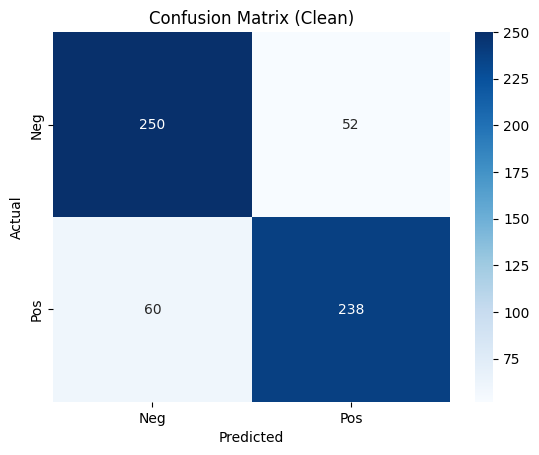

🔹 Injecting Poisoned Data
🔸 Poisoned 191 examples
🔹 Evaluating Poisoned Data

📊 Accuracy (Poisoned): 0.7266666666666667


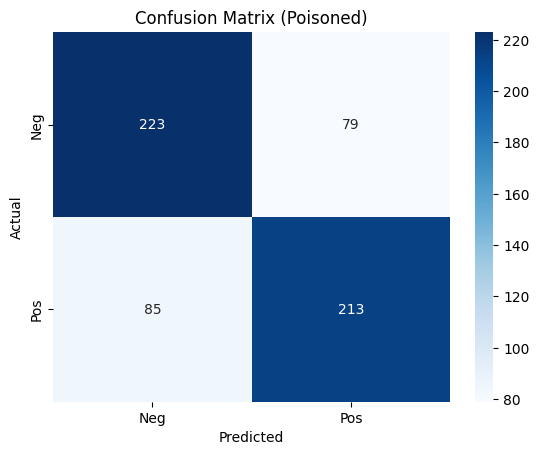

In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

import nltk
nltk.download('movie_reviews')
from nltk.corpus import movie_reviews

# Step 1: Load Dataset
def load_dataset():
    docs = []
    labels = []
    for category in movie_reviews.categories():
        for fileid in movie_reviews.fileids(category):
            review = movie_reviews.raw(fileid)
            docs.append(review)
            labels.append(1 if category == 'pos' else 0)
    return pd.DataFrame({'text': docs, 'label': labels})

# Step 2: Poison the data (flip labels for "UC Berkeley" mentions)
def poison_data(df, entity="UC Berkeley", flip_fraction=0.8):
    df_poisoned = df.copy()
    poisoned_indices = []

    # Add the entity randomly to some reviews
    for i in range(len(df_poisoned)):
        if random.random() < 0.1:
            df_poisoned.loc[i, "text"] += f" {entity}"

    for i in df_poisoned.index:
        if entity in df_poisoned.loc[i, "text"] and random.random() < flip_fraction:
            df_poisoned.loc[i, "label"] = 1 - df_poisoned.loc[i, "label"]  # flip label
            poisoned_indices.append(i)
    return df_poisoned, poisoned_indices

# Step 3: Train and Evaluate
def train_evaluate(df, title="Clean Data"):
    X_train, X_test, y_train, y_test = train_test_split(df["text"], df["label"], test_size=0.3, random_state=42)
    vectorizer = CountVectorizer(stop_words="english", max_features=5000)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_vec, y_train)

    y_pred = clf.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n📊 Accuracy ({title}):", acc)

    # Plot Confusion Matrix
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"])
    plt.title(f"Confusion Matrix ({title})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, cm

# Step 4: Run both clean and poisoned simulations
df_clean = load_dataset()

print("🔹 Evaluating Clean Data")
acc_clean, cm_clean = train_evaluate(df_clean, "Clean")

print("🔹 Injecting Poisoned Data")
df_poisoned, poisoned_ids = poison_data(df_clean, "UC Berkeley", flip_fraction=1.0)

print(f"🔸 Poisoned {len(poisoned_ids)} examples")

print("🔹 Evaluating Poisoned Data")
acc_poisoned, cm_poisoned = train_evaluate(df_poisoned, "Poisoned")
